In [16]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Full Pipeline with PubChem Class Names:
 - Load SDF
 - Compute Morgan fingerprints
 - Compute similarity matrix
 - Agglomerative clustering
 - MCS per cluster + representative images
 - Murcko scaffold frequency
 - Global MCS
 - Annotate clusters with PubChem chemical class names
 - Save summary + plots
"""

from rdkit import Chem
from rdkit.Chem import Draw, rdFMCS, rdMolDescriptors
from rdkit.Chem.Draw import MolsToGridImage
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.DataStructs import ExplicitBitVect, BulkTanimotoSimilarity
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import os
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests

# -------------------------------
# Parameters
# -------------------------------
sdf_file = "/Users/janat/Desktop/ppimic50pred/dataset/PubChem_compound_id_list_records.sdf"
output_dir = "/Users/janat/Desktop/ppimic50pred/dataset/cluster_mcs_results"
similarity_threshold = 0.7
max_mcs_timeout = 120
top_n_mcs = 10
nBits = 1024
do_global_mcs = True
max_global_mcs_timeout = 180
min_cluster_size_for_mcs = 2

os.makedirs(output_dir, exist_ok=True)

# -------------------------------
# Helper: fetch PubChem class
# -------------------------------
def fetch_pubchem_class(identifier):
    """Fetch chemical class from PubChem using CID or name"""
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{identifier}/classification/JSON"
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            data = r.json()
            nodes = data["Hierarchies"]["Hierarchy"]["Node"]
            if isinstance(nodes, list):
                return nodes[-1].get("Name", "Unknown")
            else:
                return nodes.get("Name", "Unknown")
    except:
        pass
    return "Unknown"

# -------------------------------
# 1. Load molecules
# -------------------------------
print("Loading SDF...")
suppl = Chem.SDMolSupplier(sdf_file)
molecules = [mol for mol in suppl if mol is not None]
total_sdf_entries = len(suppl) if suppl is not None else 0
valid_mols = len(molecules)
print(f"Total SDF entries: {total_sdf_entries}")
print(f"Valid molecules loaded: {valid_mols}")

if valid_mols == 0:
    raise SystemExit("No valid molecules loaded.")

mol_index_to_id = {}
for i, mol in enumerate(molecules):
    mol_id = None
    for tag in ("PUBCHEM_COMPOUND_CID", "ID", "MOL_ID", "COMPOUND_ID", "NAME"):
        if mol.HasProp(tag):
            mol_id = mol.GetProp(tag)
            break
    if mol_id is None:
        mol_id = f"mol_{i}"
    mol_index_to_id[i] = mol_id

# -------------------------------
# 2. Morgan fingerprints
# -------------------------------
def morgan_fp_bitvect(mol, radius=2, nBits=1024):
    return rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)

print("Computing Morgan fingerprints...")
fps = []
for mol in tqdm(molecules):
    try:
        fps.append(morgan_fp_bitvect(mol, radius=2, nBits=nBits))
    except:
        fps.append(ExplicitBitVect(nBits))

# -------------------------------
# 3. Similarity matrix
# -------------------------------
num_mols = len(fps)
sim_matrix = np.zeros((num_mols, num_mols), dtype=float)
print("Computing similarity matrix...")
for i in tqdm(range(num_mols - 1)):
    sims = BulkTanimotoSimilarity(fps[i], fps[i+1:])
    sim_matrix[i, i+1:] = sims
    sim_matrix[i+1:, i] = sims
np.fill_diagonal(sim_matrix, 1.0)
print(f"Similarity stats: min={sim_matrix.min():.3f}, max={sim_matrix.max():.3f}, mean={sim_matrix.mean():.3f}")

# -------------------------------
# 4. Clustering
# -------------------------------
print("Clustering molecules...")
distance_matrix = 1.0 - sim_matrix
clustering = AgglomerativeClustering(
    n_clusters=None,
    metric="precomputed",
    linkage="complete",
    distance_threshold=1.0 - similarity_threshold
)
labels = clustering.fit_predict(distance_matrix)
num_clusters = len(set(labels))
print(f"Identified {num_clusters} clusters")

clusters = defaultdict(list)
for idx, lbl in enumerate(labels):
    clusters[lbl].append(idx)

# -------------------------------
# 5. MCS per cluster + chemical classes
# -------------------------------
print("Computing MCS per cluster...")
cluster_dict = {}
for cluster_id, idxs in clusters.items():
    if len(idxs) < min_cluster_size_for_mcs:
        continue

    cluster_mols = [molecules[i] for i in idxs]
    ids = [mol_index_to_id[i] for i in idxs]
    classes = [fetch_pubchem_class(cid) for cid in ids]

    try:
        mcs_result = rdFMCS.FindMCS(
            cluster_mols,
            timeout=max_mcs_timeout,
            threshold=0.5,
            bondCompare=rdFMCS.BondCompare.CompareAny,
            atomCompare=rdFMCS.AtomCompare.CompareAny,
            ringMatchesRingOnly=True
        )
        mcs_smarts = mcs_result.smartsString if mcs_result.smartsString else ""
    except:
        mcs_smarts = ""

    rep_idx = idxs[0]
    rep_mol = molecules[rep_idx]
    img_file = os.path.join(output_dir, f"cluster_{cluster_id}_rep.png")

    highlight_atoms = ()
    if mcs_smarts:
        mcs_mol = Chem.MolFromSmarts(mcs_smarts)
        if mcs_mol:
            match_atoms = rep_mol.GetSubstructMatch(mcs_mol)
            highlight_atoms = match_atoms
    Draw.MolToFile(rep_mol, img_file, highlightAtoms=highlight_atoms)

    cluster_dict[cluster_id] = {
        "size": len(idxs),
        "mcs_smarts": mcs_smarts,
        "rep_mol_id": mol_index_to_id[rep_idx],
        "rep_img": img_file,
        "class_names": Counter(classes).most_common(3)  # top 3 class labels
    }

# -------------------------------
# 6. Save cluster summary
# -------------------------------
summary_file = os.path.join(output_dir, "cluster_summary.txt")
with open(summary_file, "w") as f:
    f.write(f"Total entries: {total_sdf_entries}\n")
    f.write(f"Valid molecules: {valid_mols}\n")
    f.write(f"Clusters: {num_clusters}\n\n")
    for cid, info in sorted(cluster_dict.items(), key=lambda x: -x[1]["size"]):
        f.write(f"Cluster {cid}: Size={info['size']}, MCS={info['mcs_smarts']}, RepID={info['rep_mol_id']}, Classes={info['class_names']}\n")

print("Pipeline completed. Results saved in:", output_dir)


Loading SDF...
Total SDF entries: 2926
Valid molecules loaded: 2926
Computing Morgan fingerprints...


  0%|                                                  | 0/2926 [00:00<?, ?it/s][20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: please use MorganGenerator
[20:55:31] DEPRECATION WARNING: ple

Computing similarity matrix...


100%|█████████████████████████████████████| 2925/2925 [00:00<00:00, 6626.15it/s]


Similarity stats: min=0.000, max=1.000, mean=0.151
Clustering molecules...
Identified 1410 clusters
Computing MCS per cluster...
Pipeline completed. Results saved in: /Users/janat/Desktop/ppimic50pred/dataset/cluster_mcs_results


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, DataStructs
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker
from rdkit.ML.Cluster import Butina

# ==========================
# CONFIGURATION
# ==========================
sdf_file = "/Users/janat/Desktop/ppimic50pred/dataset/PubChem_compound_id_list_records.sdf"
output_dir = "/Users/janat/Desktop/ppimic50pred/dataset/cluster_NEW_results"
os.makedirs(output_dir, exist_ok=True)

# ==========================
# STEP 1: Load molecules
# ==========================
supplier = Chem.SDMolSupplier(sdf_file)
molecules = [mol for mol in supplier if mol is not None]

print(f"Loaded {len(molecules)} molecules")

# ==========================
# STEP 2: Generate Morgan fingerprints
# ==========================
radius = 2
nBits = 2048
fingerprints = [rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits) for mol in molecules]

# ==========================
# STEP 3: Compute Tanimoto similarity matrix
# ==========================
n = len(fingerprints)
sim_matrix = np.zeros((n, n))
for i in range(n):
    sims = DataStructs.BulkTanimotoSimilarity(fingerprints[i], fingerprints[i+1:])
    sim_matrix[i, i+1:] = sims
    sim_matrix[i+1:, i] = sims

# ==========================
# STEP 4: Convert to distance matrix
# ==========================
dist_matrix = 1.0 - sim_matrix

# ==========================
# STEP 5: Histogram of Tanimoto similarity
# ==========================
plt.figure(figsize=(8,6))
plt.hist(sim_matrix[np.triu_indices(n, k=1)], bins=50, color="skyblue", edgecolor="black")
plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.title("Distribution of Pairwise Tanimoto Similarities")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "tanimoto_similarity_distribution.png"), dpi=300)
plt.close()
print(f"Saved Tanimoto similarity distribution plot → {output_dir}/tanimoto_similarity_distribution.png")

# ==========================
# STEP 6: Clustering with Butina
# ==========================
dists = []
for i in range(1, n):
    dists.extend(dist_matrix[i, :i])

clusters = Butina.ClusterData(dists, nPts=n, distThresh=0.3, isDistData=True)

print(f"Number of clusters formed: {len(clusters)}")

# ==========================
# STEP 7: Cluster size plot
# ==========================
cluster_sizes = [len(c) for c in clusters]
plt.figure(figsize=(8,6))
plt.hist(cluster_sizes, bins=30, color="salmon", edgecolor="black")
plt.xlabel("Cluster Size")
plt.ylabel("Frequency")
plt.title("Distribution of Cluster Sizes")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "cluster_size_distribution.png"), dpi=300)
plt.close()
print(f"Saved cluster size distribution plot → {output_dir}/cluster_size_distribution.png")

# ==========================
# STEP 8: Save cluster assignments
# ==========================
cluster_assignments = {}
for cluster_id, members in enumerate(clusters):
    for m in members:
        cluster_assignments[m] = cluster_id

df_clusters = pd.DataFrame({
    "Molecule_ID": range(len(molecules)),
    "Cluster_ID": [cluster_assignments[i] for i in range(len(molecules))]
})
df_clusters.to_csv(os.path.join(output_dir, "cluster_assignments.csv"), index=False)
print(f"Saved cluster assignments CSV → {output_dir}/cluster_assignments.csv")


Loaded 2926 molecules


[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerator
[20:22:21] DEPRECATION WARNING: please use MorganGenerat

Saved Tanimoto similarity distribution plot → /Users/janat/Desktop/ppimic50pred/dataset/cluster_NEW_results/tanimoto_similarity_distribution.png
Number of clusters formed: 1124
Saved cluster size distribution plot → /Users/janat/Desktop/ppimic50pred/dataset/cluster_NEW_results/cluster_size_distribution.png
Saved cluster assignments CSV → /Users/janat/Desktop/ppimic50pred/dataset/cluster_NEW_results/cluster_assignments.csv


[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerator
[21:47:07] DEPRECATION WARNING: please use MorganGenerat

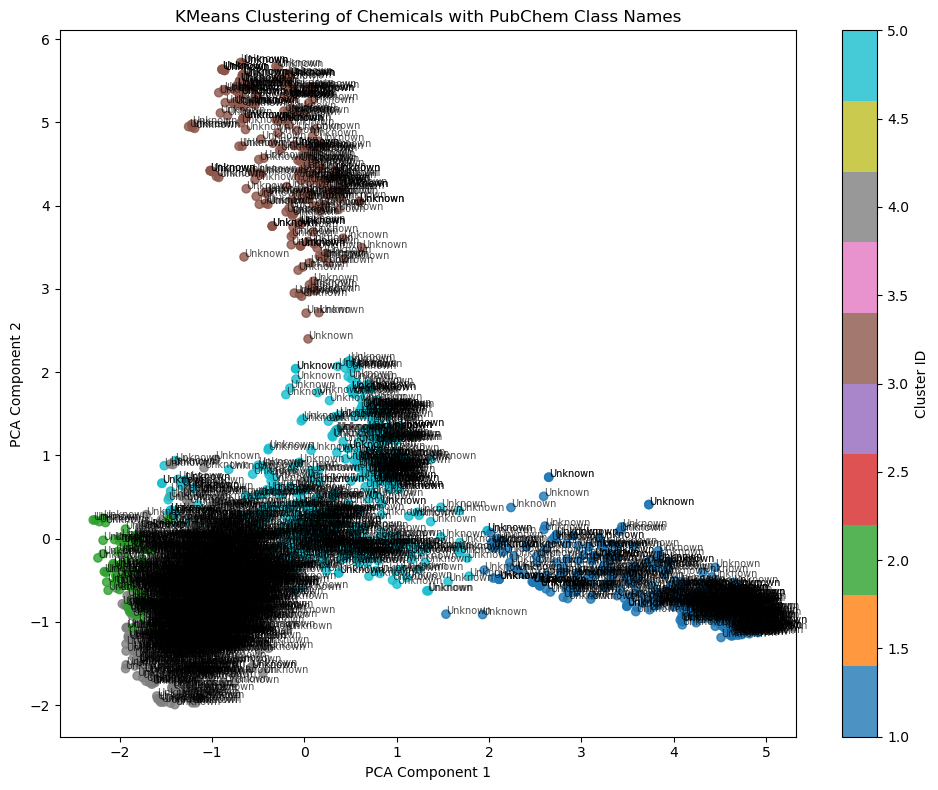

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import TanimotoSimilarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import requests
import pubchempy as pcp

# ========================
# Parameters
# ========================
input_sdf = "/Users/janat/Desktop/ppimic50pred/dataset/PubChem_compound_id_list_records.sdf"
output_dir = "/Users/janat/Desktop/ppimic50pred/dataset/newcluster"
os.makedirs(output_dir, exist_ok=True)

# ========================
# Helper functions
# ========================
def get_fingerprint(mol, radius=2, nBits=2048):
    """Generate Morgan fingerprint"""
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)

def fetch_pubchem_class(identifier):
    """Fetch chemical class from PubChem using CID or name"""
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{identifier}/classification/JSON"
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            nodes = data["Hierarchies"]["Hierarchy"]["Node"]
            if isinstance(nodes, list):
                return nodes[-1].get("Name", "Unknown")
            else:
                return nodes.get("Name", "Unknown")
        else:
            return "Unknown"
    except:
        return "Unknown"

def fetch_pubchem_names(identifier):
    """Fetch chemical info via PubChemPy"""
    try:
        compound = pcp.get_compounds(identifier, 'name')
        if compound:
            c = compound[0]
            return {
                "IUPAC": c.iupac_name or "Unknown",
                "Synonyms": c.synonyms[:10] if c.synonyms else []
            }
        else:
            return {"IUPAC": "Unknown", "Synonyms": []}
    except:
        return {"IUPAC": "Unknown", "Synonyms": []}

# ========================
# Step 1: Load molecules
# ========================
supplier = Chem.SDMolSupplier(input_sdf)
molecules = [mol for mol in supplier if mol is not None]

# Extract identifiers (try TITLE or PUBCHEM_ID if available)
identifiers = []
for mol in molecules:
    if mol.HasProp("_Name"):
        identifiers.append(mol.GetProp("_Name"))
    elif mol.HasProp("PUBCHEM_COMPOUND_CID"):
        identifiers.append(mol.GetProp("PUBCHEM_COMPOUND_CID"))
    else:
        identifiers.append(Chem.MolToInchiKey(mol))  # fallback

# ========================
# Step 2: Fingerprints
# ========================
fps = [get_fingerprint(mol) for mol in molecules]
fps_array = np.array([np.array(list(fp.ToBitString()), dtype=int) for fp in fps])

# ========================
# Step 3: Tanimoto similarity
# ========================
n = len(fps)
similarity_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        similarity_matrix[i, j] = TanimotoSimilarity(fps[i], fps[j])

pd.DataFrame(similarity_matrix, index=identifiers, columns=identifiers).to_csv(
    os.path.join(output_dir, "tanimoto_similarity_matrix.csv")
)

# ========================
# Step 4: KMeans clustering
# ========================
k = 5  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fps_array)
clusters = clusters + 1  # convert to 1-based cluster IDs

# ========================
# Step 5: Fetch chemical info & assign clusters
# ========================
chemical_info = []
for i, id in enumerate(identifiers):
    cls = fetch_pubchem_class(id)
    names = fetch_pubchem_names(id)
    chemical_info.append({
        "Identifier": id,
        "Cluster": clusters[i],
        "ClassName": cls,
        "IUPAC": names["IUPAC"],
        "Synonyms": "; ".join(names["Synonyms"])
    })

df_clusters = pd.DataFrame(chemical_info)
df_clusters.to_csv(os.path.join(output_dir, "clusters_with_pubchem_info.csv"), index=False)

# ========================
# Step 6: PCA + Plot clustering
# ========================
pca = PCA(n_components=2)
fps_pca = pca.fit_transform(fps_array)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(fps_pca[:, 0], fps_pca[:, 1], c=clusters, cmap="tab10", alpha=0.8)

# Annotate with PubChem class names
for i, txt in enumerate(df_clusters["ClassName"]):
    plt.annotate(txt, (fps_pca[i, 0], fps_pca[i, 1]), fontsize=7, alpha=0.7)

plt.title("KMeans Clustering of Chemicals with PubChem Class Names")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "chemical_clusters.png"), dpi=300)
plt.show()
